# `DiscreteControlLoopSimulator` demo: stabilizing a 1D linear-Gaussian system

This notebook demonstrates `dynestyx.discrete_controller_simulators.DiscreteControlLoopSimulator`, which implements the online control loop

```
x_0 ~ p(x_0)
y_0 | x_0 ~ p(y_0 | x_0, t_0)
x_hat_{0|0} = FilterUpdate(y_0, t_0)
u_k, s_{k+1} = control_policy(x_hat_{k|k}, s_k)
x_{k+1} | x_k, u_k ~ p(x_{k+1} | x_k, u_k, t_k, t_{k+1})
y_{k+1} | x_{k+1}, u_k ~ p(y_{k+1} | x_{k+1}, u_k, t_{k+1})
x_hat_{k+1|k+1} = FilterUpdate(x_hat_{k|k}, u_k, y_{k+1}, t_k, t_{k+1})
```

at each step, sampling the next state and observation, filtering the observation into an updated belief, and asking the policy for the next control -- all online, unlike `DiscreteTimeSimulator`, which requires the entire control trajectory to be supplied up front.

We use:
1. a simple 1D linear-Gaussian dynamical system (a noisy random walk, `x_{k+1} = A x_k + B u_k + noise`) with the full state directly observed under Gaussian noise,
2. a linear feedback policy `u_k = -K x_hat_k` that drives the state toward 0,
3. a plot comparing the controlled trajectory against an uncontrolled (`K=0`) baseline.

In [1]:
import equinox as eqx
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from numpyro.handlers import seed

import dynestyx as dsx
from dynestyx.discrete_controller_simulators import DiscreteControlLoopSimulator, filter_state_mean
from dynestyx.inference.filter_configs import KFConfig
from dynestyx.models import DynamicalModel
from dynestyx.models.observations import LinearGaussianObservation
from dynestyx.models.state_evolution import LinearGaussianStateEvolution

## 1. Define the dynamics

`state_dim = control_dim = observation_dim = 1`. The transition is `x_{k+1} = A x_k + B u_k + noise`, with `A = 1` -- a marginally-unstable random walk when uncontrolled, so the effect of feedback control is visually obvious. The observation model directly observes the full state under additive Gaussian noise (`H = I`, no control dependence).

In [2]:
state_dim = control_dim = obs_dim = 1

dynamics = DynamicalModel(
    initial_condition=dist.MultivariateNormal(jnp.array([5.0]), 0.1 * jnp.eye(state_dim)),
    state_evolution=LinearGaussianStateEvolution(
        A=jnp.array([[1.0]]), B=jnp.array([[1.0]]), cov=0.05 * jnp.eye(state_dim)
    ),
    observation_model=LinearGaussianObservation(
        H=jnp.eye(obs_dim, state_dim), R=0.2 * jnp.eye(obs_dim)
    ),
    control_dim=control_dim,
)

## 2. Define the controller

A simple linear feedback policy `u = -K x_hat`, implemented as an `equinox.Module` (per the control-loop's requirement that the policy be any callable, e.g. a learned neural policy or, as here, a fixed gain). `filter_state_mean` extracts a point estimate from whatever filter-family belief `DiscreteControlLoopSimulator` produces (Kalman-family states expose `.mean` directly; particle-filter states are summarized as a weighted mean instead), so the same policy code works regardless of `filter_config`.

With `A - B*K = 1 - 0.5 = 0.5`, well inside the unit circle, the closed loop should converge to 0.

In [3]:
class LinearPolicy(eqx.Module):
    K: jnp.ndarray

    def __call__(self, x_hat, s):
        return -self.K @ filter_state_mean(x_hat), s

## 3. Run the closed loop, with and without control

`DiscreteControlLoopSimulator` is used the same way as any other dynestyx simulator: `with sim: dsx.sample(name, dynamics, predict_times=...)` inside a model function, run under a seeded NumPyro context. We use `predict_times` (not `obs_times`/`ctrl_times`) since this is forward rollout with no conditioning and no pre-supplied controls -- the whole point is that the trajectory doesn't exist yet until the loop generates it. `filter_config=KFConfig(record_filtered_states_mean=True)` makes the filtered state estimate available as an output (it's needed internally either way, for the policy; this only controls whether it's also returned). We run twice: once with the stabilizing gain `K=0.5`, once with `K=0` (no control) as a baseline.

In [4]:
predict_times = jnp.arange(0.0, 30.0)


def run(K: float):
    policy = LinearPolicy(K=jnp.array([[K]]))

    def model():
        with DiscreteControlLoopSimulator(
            control_policy=policy,
            policy_state_init=None,
            filter_config=KFConfig(record_filtered_states_mean=True),
        ):
            return dsx.sample("loop", dynamics, predict_times=predict_times)

    with seed(rng_seed=0):
        return numpyro.handlers.trace(model).get_trace()


trace_controlled = run(K=0.5)
trace_uncontrolled = run(K=0.0)

## 4. Plot the resulting dynamics

Top panel: noisy observations (dots) and the filtered state estimate (line) for both runs -- since the full state is directly observed here, the observations already closely track the true state, and the filtered estimate smooths out the sensor noise. Bottom panel: the control sequence chosen online by the policy for the controlled run.

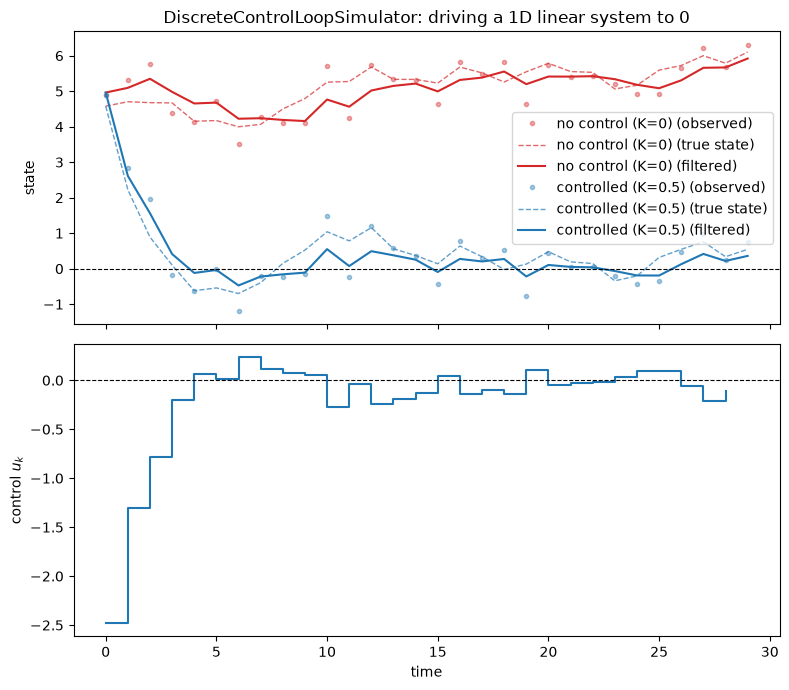

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

runs = [
    (trace_uncontrolled, "no control (K=0)", "tab:red"),
    (trace_controlled, "controlled (K=0.5)", "tab:blue"),
]
for trace, label, color in runs:
    t = trace["loop_times"]["value"][0]
    true_state = trace["loop_states"]["value"][0, :, 0]
    obs = trace["loop_observations"]["value"][0, :, 0]
    filtered_mean = trace["loop_filtered_states_mean"]["value"][0, :, 0]
    axes[0].plot(t, obs, ".", color=color, alpha=0.4, label=f"{label} (observed)")
    axes[0].plot(t, true_state, "--", color=color, alpha=0.7, linewidth=1, label=f"{label} (true state)")
    axes[0].plot(t, filtered_mean, "-", color=color, label=f"{label} (filtered)")

axes[0].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("state")
axes[0].legend()
axes[0].set_title("DiscreteControlLoopSimulator: driving a 1D linear system to 0")

t_u = trace_controlled["loop_times"]["value"][0][:-1]
u = trace_controlled["loop_controls"]["value"][0, :, 0]
axes[1].step(t_u, u, where="post", color="tab:blue")
axes[1].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("control $u_k$")
axes[1].set_xlabel("time")

plt.tight_layout()
plt.show()